In [ ]:
import pandas as pd

benin = pd.read_csv("data/benin_clean.csv")
sierra_leone = pd.read_csv("data/sierraleone_clean.csv")
togo = pd.read_csv("data/togo_clean.csv")

# Add a country column to each
benin["Country"] = "Benin"
sierra_leone["Country"] = "Sierra Leone"
togo["Country"] = "Togo"

# Combine into one DataFrame
df_all = pd.concat([benin, sierra_leone, togo], ignore_index=True)


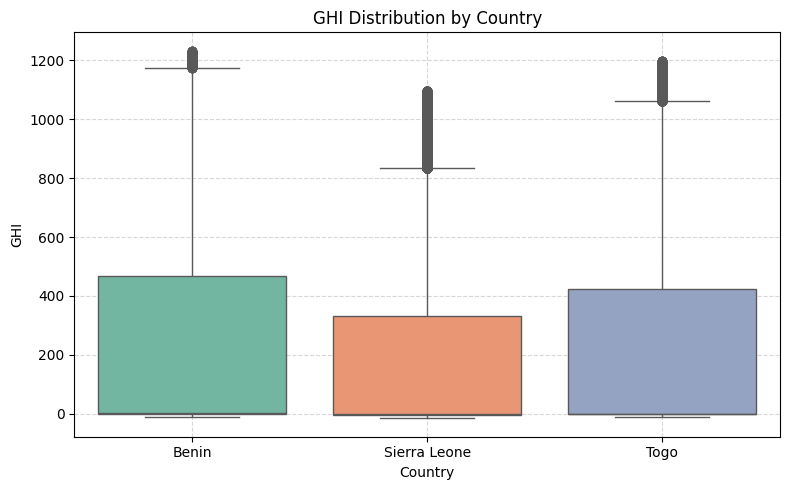

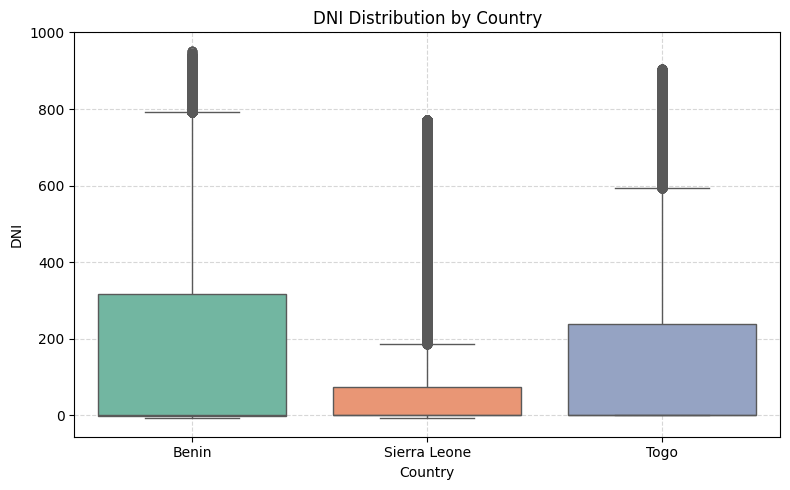

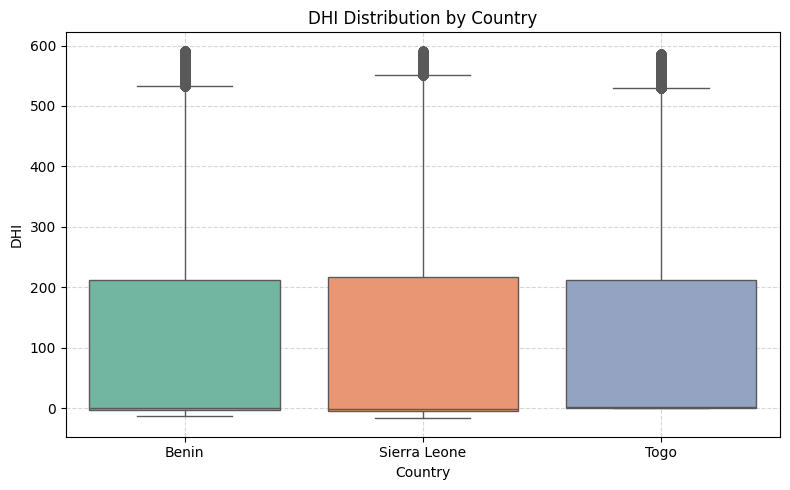

In [ ]:
# Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt

# list of solar radiation metrics to compare across countries
metrics = ["GHI", "DNI", "DHI"]

# Loop through each metric to create a boxplot
for metric in metrics:
    plt.figure(figsize=(8, 5))
     # Create a boxplot for the current metric, grouped by country
    sns.boxplot(data=df_all, x="Country", y=metric, hue="Country", palette="Set2", dodge=False, legend=False)
    plt.title(f"{metric} Distribution by Country")
    plt.xlabel("Country")
    plt.ylabel(metric)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()



In [ ]:
#Summary Table (mean, median, std)
summary_table = df_all.groupby("Country")[["GHI", "DNI", "DHI"]].agg(["mean", "median", "std"]).round(2)
print(summary_table)


                 GHI                    DNI                    DHI         \
                mean median     std    mean median     std    mean median   
Country                                                                     
Benin         236.23    0.7  328.29  166.90   -0.1  262.08  111.66    0.5   
Sierra Leone  185.00   -0.4  279.02  104.13   -0.1  200.95  108.10   -0.6   
Togo          223.86    0.5  317.31  147.98    0.0  247.68  112.78    1.5   

                      
                 std  
Country               
Benin         153.10  
Sierra Leone  153.69  
Togo          151.57  


In [ ]:
#Statistical Testing: One-way ANOVA
from scipy.stats import f_oneway


# Perform one-way ANOVA to compare the mean GHI values across the three countries
f_stat, p_val = f_oneway(
    benin["GHI"],
    sierra_leone["GHI"],
    togo["GHI"]
)
# Print the results of the ANOVA test
print(f"ANOVA Result: F = {f_stat:.2f}, p = {p_val:.4f}")


ANOVA Result: F = 3833.18, p = 0.0000


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127774 (\N{SUN WITH FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


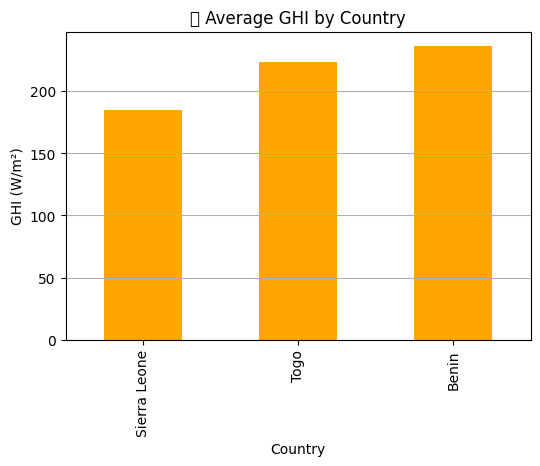

In [ ]:
# Bonus: Visual Summary (Bar chart of avg GHI)

# Group the data by country and calculate the mean GHI for each
avg_ghi = df_all.groupby("Country")["GHI"].mean().sort_values()

# Plot the average GHI as a bar chart
avg_ghi.plot(kind="bar", color="orange", figsize=(6,4), title="🌞 Average GHI by Country")
plt.ylabel("GHI (W/m²)")
plt.grid(axis='y')
plt.show()
